# Trace Count v3: v2 Attention-Head Ablation and Total-Token Attention

这个 notebook 不再训练新的 v3 模型。它直接读取 v2 训练好的 `thinking` checkpoint，专门回答一个机制问题：

> 在 `<Think/> <1> x <2> y <3> z </Think>` 这种 trace 里，最后一个计数数字 token（例如 `<3>`）的 attention 到底主要看哪里？
> 是在找 prompt 里的最后一次 needle，还是只看上一个 trace 数字 / marker 然后做 `+1`？

核心输出：

- **total-token attention decomposition**：把每个 head 的 attention 拆成 prompt needle、prompt noise、上一个 trace 数字、上一个 trace marker 等类别；
- **last-index analysis**：单独看最后一个 trace 数字 `<n>`；
- **head ablation**：把最像 targeted retrieval 的 head、最像 local `+1` 的 head、control head 分别 ablate，看 trace 和 final answer 是否掉点。

注意：本文里的 `layer` 是 **1-based**，`head` 是 **0-based**，和 v2 报告保持一致。
        

## 1. Environment and Repo Setup

In [6]:
from __future__ import annotations

from pathlib import Path
import json
import math
import os
import random
import shutil
import subprocess
import sys
from contextlib import contextmanager
from dataclasses import dataclass
from datetime import datetime
from typing import Any

REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
INSTALL_DEPS = False
FIX_NUMPY_ABI = False  # set True only if pandas/scipy complains about NumPy dtype size

IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()
if IN_COLAB:
    repo_dir = Path("/content/Synthetic_CoT_NiaH_Count")
    cwd = Path.cwd()
    if (cwd / ".git").exists() or (cwd / "notebooks" / "Trace_Count_v2_Colab.ipynb").exists():
        repo_dir = cwd
    elif (repo_dir / ".git").exists() or (repo_dir / "notebooks" / "Trace_Count_v2_Colab.ipynb").exists():
        pass
    elif repo_dir.exists() and any(repo_dir.iterdir()):
        print(f"Using existing non-git directory: {repo_dir}")
    else:
        subprocess.run(["git", "clone", REPO_URL, str(repo_dir)], check=True)
    os.chdir(repo_dir)

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if INSTALL_DEPS:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "transformers>=4.40", "seaborn", "tqdm"],
        check=True,
    )
if FIX_NUMPY_ABI:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--force-reinstall",
            "numpy<2",
            "pandas",
            "matplotlib",
            "seaborn",
            "scipy",
        ],
        check=True,
    )
    raise RuntimeError("NumPy ABI repair finished. Restart the runtime/kernel, then rerun with FIX_NUMPY_ABI = False.")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from tqdm.auto import tqdm
from transformers import GPT2LMHeadModel

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

display(Markdown(f"**Repo root:** `{ROOT}`"))
display(Markdown(f"**Device available:** `{'cuda' if torch.cuda.is_available() else 'cpu'}`"))
        

**Repo root:** `/content/Synthetic_CoT_NiaH_Count`

**Device available:** `cuda`

## 2. Runtime Settings

In [7]:
# Set this if the automatic resolver does not find your v2 run.
# Examples:
# V2_RUN_DIR_OVERRIDE = "runs/v2_marker_trace_seed1234_main"
# V2_RUN_DIR_OVERRIDE = "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run"
V2_RUN_DIR_OVERRIDE = ""
AUTO_MOUNT_DRIVE_FOR_V2_INPUTS = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Analysis size. Increase after the notebook is working.
ATTENTION_EXAMPLES_PER_COUNT = 40
ABLATION_EXAMPLES_PER_COUNT = 40
RANDOM_SEED = 1234

RUN_ATTENTION_DECOMPOSITION = True
RUN_HEAD_ABLATION = True
REUSE_EXISTING_TABLES = True

print({
    "V2_RUN_DIR_OVERRIDE": V2_RUN_DIR_OVERRIDE or "<auto>",
    "AUTO_MOUNT_DRIVE_FOR_V2_INPUTS": AUTO_MOUNT_DRIVE_FOR_V2_INPUTS,
    "DEVICE": DEVICE,
    "ATTENTION_EXAMPLES_PER_COUNT": ATTENTION_EXAMPLES_PER_COUNT,
    "ABLATION_EXAMPLES_PER_COUNT": ABLATION_EXAMPLES_PER_COUNT,
    "RUN_ATTENTION_DECOMPOSITION": RUN_ATTENTION_DECOMPOSITION,
    "RUN_HEAD_ABLATION": RUN_HEAD_ABLATION,
})
        

{'V2_RUN_DIR_OVERRIDE': '<auto>', 'AUTO_MOUNT_DRIVE_FOR_V2_INPUTS': True, 'DEVICE': 'cuda', 'ATTENTION_EXAMPLES_PER_COUNT': 40, 'ABLATION_EXAMPLES_PER_COUNT': 40, 'RUN_ATTENTION_DECOMPOSITION': True, 'RUN_HEAD_ABLATION': True}


## 3. v2 Vocabulary, Data, and Rendering

这里复刻 v2 的 synthetic NIAH-counting 任务定义：

- prompt 里有 `1..10` 个 marker needle；
- marker token 是 `<A>` 到 `<J>`；
- noise token 是 `<N0>` 到 `<N63>`；
- thinking 模型看到 prompt 后生成 indexed trace：`<1> marker_1 <2> marker_2 ... <n> marker_n`。

后面的 attention 分析依赖精确 token 位置，所以这里会记录 prompt needle、trace index、trace marker、`<Think/>`、`</Think>`、`<Ans>` 等 anchor。
        

In [8]:
SPECIAL_TOKENS = ["<PAD>", "<BOS>", "<EOS>", "<Ans>", "<Think/>", "</Think>"]
NOISE_TOKENS = [f"<N{i}>" for i in range(64)]
MARKER_TOKENS = [f"<{chr(ord('A') + i)}>" for i in range(10)]
NUMBER_TOKENS = [f"<{i}>" for i in range(1, 11)]
COUNT_BINS = {"low": {1, 2, 3}, "mid": {4, 5, 6}, "high": {7, 8, 9, 10}}


def count_bin(count: int) -> str:
    for name, values in COUNT_BINS.items():
        if int(count) in values:
            return name
    raise ValueError(count)


@dataclass
class Vocab:
    token_to_id: dict[str, int]
    id_to_token: list[str]

    @classmethod
    def build(cls) -> "Vocab":
        tokens = SPECIAL_TOKENS + NOISE_TOKENS + MARKER_TOKENS + NUMBER_TOKENS
        return cls({tok: i for i, tok in enumerate(tokens)}, tokens)

    @classmethod
    def load(cls, path: Path) -> "Vocab":
        obj = json.loads(path.read_text(encoding="utf-8"))
        return cls(obj["token_to_id"], obj["id_to_token"])

    def encode(self, tokens: list[str]) -> list[int]:
        return [self.token_to_id[tok] for tok in tokens]

    def decode(self, ids: list[int]) -> list[str]:
        return [self.id_to_token[int(i)] for i in ids]

    @property
    def pad_id(self) -> int:
        return self.token_to_id["<PAD>"]

    @property
    def eos_id(self) -> int:
        return self.token_to_id["<EOS>"]

    @property
    def numeric_ids(self) -> list[int]:
        return [self.token_to_id[tok] for tok in NUMBER_TOKENS]

    def count_to_token(self, count: int) -> str:
        return f"<{int(count)}>"

    def token_to_count(self, token: str) -> int | None:
        if token.startswith("<") and token.endswith(">"):
            inner = token[1:-1]
            if inner.isdigit() and 1 <= int(inner) <= 10:
                return int(inner)
        return None


@dataclass
class BaseExample:
    seq_tokens: list[str]
    count: int
    needle_positions: list[int]
    needle_markers: list[str]
    seed: int | None = None


def validate_base_example(ex: BaseExample, seq_len: int) -> None:
    assert len(ex.seq_tokens) == seq_len
    assert 1 <= ex.count <= 10
    assert ex.count == len(ex.needle_positions) == len(ex.needle_markers)
    assert ex.needle_positions == sorted(ex.needle_positions)
    assert all(ex.seq_tokens[pos] == marker for pos, marker in zip(ex.needle_positions, ex.needle_markers))
    assert sum(tok in MARKER_TOKENS for tok in ex.seq_tokens) == ex.count


def sample_base_example(seq_len: int, rng: random.Random, *, count: int | None = None, seed: int | None = None) -> BaseExample:
    n = rng.randint(1, 10) if count is None else int(count)
    positions = sorted(rng.sample(range(seq_len), n))
    markers = [rng.choice(MARKER_TOKENS) for _ in range(n)]
    seq = [rng.choice(NOISE_TOKENS) for _ in range(seq_len)]
    for pos, marker in zip(positions, markers):
        seq[pos] = marker
    ex = BaseExample(seq, n, positions, markers, seed)
    validate_base_example(ex, seq_len)
    return ex


def balanced_examples(seq_len: int, examples_per_count: int, seed: int) -> list[BaseExample]:
    rng = random.Random(seed)
    examples = []
    for count in range(1, 11):
        for i in range(examples_per_count):
            examples.append(sample_base_example(seq_len, rng, count=count, seed=seed + 1000 * count + i))
    rng.shuffle(examples)
    return examples


def render_thinking(ex: BaseExample, vocab: Vocab) -> dict[str, Any]:
    trace = []
    index_positions = []
    marker_positions = []
    pre_index_positions = []
    think_start_pos = 1 + len(ex.seq_tokens)
    pos = think_start_pos + 1
    prev_marker_pos = think_start_pos
    for k, marker in enumerate(ex.needle_markers, start=1):
        pre_index_positions.append(prev_marker_pos)
        trace.extend([vocab.count_to_token(k), marker])
        index_positions.append(pos)
        marker_positions.append(pos + 1)
        prev_marker_pos = pos + 1
        pos += 2
    tokens = ["<BOS>"] + ex.seq_tokens + ["<Think/>"] + trace + ["</Think>", "<Ans>", vocab.count_to_token(ex.count), "<EOS>"]
    think_end_pos = think_start_pos + 1 + len(trace)
    ans_pos = think_end_pos + 1
    final_answer_pos = ans_pos + 1
    anchors = {
        "think_start": think_start_pos,
        "think_end": think_end_pos,
        "ans_token": ans_pos,
        "final_answer_pos": final_answer_pos,
        "prompt_start": 1,
        "prompt_end_exclusive": 1 + len(ex.seq_tokens),
        "index_positions": index_positions,
        "marker_positions": marker_positions,
        "pre_index_positions": pre_index_positions,
        "prompt_needle_positions": [1 + pos for pos in ex.needle_positions],
    }
    return {
        "tokens": tokens,
        "input_ids": vocab.encode(tokens),
        "anchors": anchors,
        "count": ex.count,
        "count_bin": count_bin(ex.count),
        "needle_positions": ex.needle_positions,
        "needle_markers": ex.needle_markers,
        "trace_tokens": [tok for k, marker in enumerate(ex.needle_markers, start=1) for tok in (vocab.count_to_token(k), marker)],
    }


def build_thinking_prefix(ex: BaseExample, vocab: Vocab) -> list[str]:
    return ["<BOS>"] + ex.seq_tokens + ["<Think/>"]


def token_role(position: int, rendered: dict[str, Any], ex: BaseExample) -> str:
    a = rendered["anchors"]
    if position == 0:
        return "bos"
    if position in a["prompt_needle_positions"]:
        j = a["prompt_needle_positions"].index(position) + 1
        return f"prompt_needle_{j}"
    if a["prompt_start"] <= position < a["prompt_end_exclusive"]:
        return "prompt_noise"
    if position == a["think_start"]:
        return "think_open"
    if position in a["index_positions"]:
        j = a["index_positions"].index(position) + 1
        return f"trace_index_{j}"
    if position in a["marker_positions"]:
        j = a["marker_positions"].index(position) + 1
        return f"trace_marker_{j}"
    if position == a["think_end"]:
        return "think_close"
    if position == a["ans_token"]:
        return "answer_token"
    if position == a["final_answer_pos"]:
        return "final_answer"
    return "other_context"
        

## 4. Locate v2 Checkpoint and Load Thinking Model

In [9]:
def latest(paths: list[Path]) -> Path | None:
    paths = [p for p in paths if p.exists()]
    if not paths:
        return None
    return sorted(paths, key=lambda p: p.stat().st_mtime, reverse=True)[0]


def maybe_mount_drive_for_v2_inputs() -> None:
    if not IN_COLAB or not AUTO_MOUNT_DRIVE_FOR_V2_INPUTS:
        return
    drive_root = Path("/content/drive/MyDrive")
    if drive_root.exists():
        return
    try:
        from google.colab import drive

        print("Mounting Google Drive to search for saved v2 checkpoints...")
        drive.mount("/content/drive")
    except Exception as e:
        print(f"Google Drive mount skipped or failed: {e}")


def candidate_v2_run_dirs() -> list[Path]:
    maybe_mount_drive_for_v2_inputs()
    out = []
    if V2_RUN_DIR_OVERRIDE:
        out.append(Path(V2_RUN_DIR_OVERRIDE))
    out.extend([
        Path("runs/v2_marker_trace_seed1234_main"),
        Path("runs/v2_marker_trace_seed1234_debug"),
    ])
    out.extend(Path("runs").glob("v2_marker_trace_seed*_main"))
    out.extend(Path("runs").glob("v2_marker_trace_seed*_debug"))
    out.extend(Path("colab_results").glob("v2_marker_trace_*_seed*/run"))
    drive_root = Path("/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results")
    if drive_root.exists():
        out.extend(drive_root.glob("v2_marker_trace_*_seed*/run"))
    # Deduplicate while preserving order.
    seen = set()
    deduped = []
    for p in out:
        key = str(p.resolve()) if p.exists() else str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    return deduped


def resolve_v2_run_dir() -> Path:
    candidates = candidate_v2_run_dirs()
    valid = []
    for p in candidates:
        if (p / "checkpoints" / "final" / "thinking" / "config.json").exists():
            valid.append(p)
    if not valid:
        display(pd.DataFrame({"candidate": [str(p) for p in candidates], "exists": [p.exists() for p in candidates]}))
        raise FileNotFoundError(
            "Could not find a v2 final thinking checkpoint. v3 is analysis-only and needs a v2 run. "
            "Run Trace_Count_v2_Colab first, copy the v2 bundle to Google Drive, or set "
            "V2_RUN_DIR_OVERRIDE to a directory containing checkpoints/final/thinking. For your usual "
            "Drive layout this is often something like "
            "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/"
            "colab_results/v2_marker_trace_main_seed1234_20260706_215757/run"
        )
    if V2_RUN_DIR_OVERRIDE:
        return valid[0]
    return latest(valid)


def load_gpt2_eager(path: Path) -> GPT2LMHeadModel:
    try:
        model = GPT2LMHeadModel.from_pretrained(path, attn_implementation="eager")
    except TypeError:
        model = GPT2LMHeadModel.from_pretrained(path)
        model.config._attn_implementation = "eager"
    model.to(DEVICE)
    model.eval()
    return model


V2_RUN_DIR = resolve_v2_run_dir()
CHECKPOINT_DIR = V2_RUN_DIR / "checkpoints"
THINKING_MODEL_DIR = CHECKPOINT_DIR / "final" / "thinking"
VOCAB_PATH = CHECKPOINT_DIR / "final" / "vocab.json"
RUN_CONFIG_PATH = V2_RUN_DIR / "config.json"

vocab = Vocab.load(VOCAB_PATH) if VOCAB_PATH.exists() else Vocab.build()
cfg = {
    "seq_len": 256,
    "max_count": 10,
    "seed": RANDOM_SEED,
    "device": DEVICE,
}
if RUN_CONFIG_PATH.exists():
    cfg.update(json.loads(RUN_CONFIG_PATH.read_text(encoding="utf-8")))
cfg["device"] = DEVICE

ANALYSIS_DIR = V2_RUN_DIR / "v3_attention_head_deepdive"
TABLE_DIR = ANALYSIS_DIR / "tables"
FIG_DIR = ANALYSIS_DIR / "figures"
for p in [ANALYSIS_DIR, TABLE_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

thinking_model = load_gpt2_eager(THINKING_MODEL_DIR)
N_LAYER = int(thinking_model.config.n_layer)
N_HEAD = int(thinking_model.config.n_head)

display(Markdown(f"**v2 run dir:** `{V2_RUN_DIR}`"))
display(Markdown(f"**thinking checkpoint:** `{THINKING_MODEL_DIR}`"))
display(Markdown(f"**model:** `{N_LAYER}` layers x `{N_HEAD}` heads, `n_embd={thinking_model.config.n_embd}`"))
display(Markdown(f"**analysis outputs:** `{ANALYSIS_DIR}`"))
        

Mounted at /content/drive


Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

**v2 run dir:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run`

**thinking checkpoint:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/checkpoints/final/thinking`

**model:** `4` layers x `4` heads, `n_embd=256`

**analysis outputs:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/v3_attention_head_deepdive`

## 5. Total-Token Attention Decomposition

这一节把每个 head 的 attention 拆成可解释类别。

**横轴/纵轴说明会在每张图前重复写清楚。这里先定义几个关键 anchor：**

- `pre_index_k`：当前 trace 数字 `<k>` 之前的位置。它的 next-token logits 负责生成 `<k>`，所以如果这里强烈看 `previous_index_token`，更像局部 `+1` / trace continuation。
- `index_token_k`：trace 数字 `<k>` 自己。它的 hidden state 负责生成后面的 marker，所以如果这里强烈看 `correct_prompt_needle`，更像用 `<k>` 去 prompt 里 targeted retrieval。
- `marker_token_k`：trace 里 `<k>` 后面的 marker token。

**“所有 trace 数字”是什么意思？**
这里的 trace 数字只指 `<Think/> ... </Think>` 中生成出来的计数 token：`<1>, <2>, ..., <n>`，不是 prompt 里的 token。对某个 query 来说，causal attention 只能看到自己和之前的 trace 数字，未来 trace 数字的 attention 理论上为 0。
        

In [10]:
CATEGORY_COLUMNS = [
    "correct_prompt_needle",
    "other_prompt_needles",
    "prompt_noise",
    "current_index_self",
    "current_marker_self",
    "previous_index_token",
    "previous_marker_token",
    "earlier_trace_tokens",
    "think_open",
    "bos",
    "other_context",
]


def mass(weights: np.ndarray, positions: set[int] | list[int]) -> float:
    positions = list(positions)
    if not positions:
        return 0.0
    valid = [p for p in positions if 0 <= p < len(weights)]
    return float(weights[valid].sum()) if valid else 0.0


def disjoint_attention_categories(weights: np.ndarray, rendered: dict[str, Any], ex: BaseExample, k: int, q_pos: int) -> dict[str, float]:
    a = rendered["anchors"]
    prompt_all = set(range(a["prompt_start"], a["prompt_end_exclusive"]))
    prompt_needles = set(a["prompt_needle_positions"])
    correct_needle = {a["prompt_needle_positions"][k - 1]}
    other_needles = prompt_needles - correct_needle
    prompt_noise = prompt_all - prompt_needles

    current_index = {a["index_positions"][k - 1]} if q_pos == a["index_positions"][k - 1] else set()
    current_marker = {a["marker_positions"][k - 1]} if q_pos == a["marker_positions"][k - 1] else set()
    previous_index = {a["index_positions"][k - 2]} if k > 1 else set()
    previous_marker = {a["marker_positions"][k - 2]} if k > 1 else set()
    previous_trace = set(a["index_positions"][: max(k - 1, 0)] + a["marker_positions"][: max(k - 1, 0)])
    earlier_trace = previous_trace - previous_index - previous_marker

    assigned = set()
    cats = {
        "correct_prompt_needle": correct_needle,
        "other_prompt_needles": other_needles,
        "prompt_noise": prompt_noise,
        "current_index_self": current_index,
        "current_marker_self": current_marker,
        "previous_index_token": previous_index,
        "previous_marker_token": previous_marker,
        "earlier_trace_tokens": earlier_trace,
        "think_open": {a["think_start"]},
        "bos": {0},
    }
    out = {}
    for name, positions in cats.items():
        positions = set(positions) - assigned
        out[name] = mass(weights, positions)
        assigned |= positions
    out["other_context"] = max(0.0, 1.0 - sum(out.values()))
    return out


def non_disjoint_metrics(weights: np.ndarray, rendered: dict[str, Any], ex: BaseExample, k: int) -> dict[str, float]:
    a = rendered["anchors"]
    prompt_needles = a["prompt_needle_positions"]
    correct = prompt_needles[k - 1]
    last = prompt_needles[ex.count - 1]
    previous_prompt = prompt_needles[k - 2] if k > 1 else None
    previous_index = a["index_positions"][k - 2] if k > 1 else None
    previous_marker = a["marker_positions"][k - 2] if k > 1 else None
    all_prev_index = a["index_positions"][: max(k - 1, 0)]
    all_prev_marker = a["marker_positions"][: max(k - 1, 0)]

    needle_weights = weights[prompt_needles]
    top_needle_idx = int(np.argmax(needle_weights)) + 1
    correct_rank = int(((-needle_weights).argsort().tolist()).index(k - 1) + 1)

    return {
        "correct_prompt_needle_mass": float(weights[correct]),
        "last_prompt_needle_mass": float(weights[last]),
        "previous_prompt_needle_mass": float(weights[previous_prompt]) if previous_prompt is not None else 0.0,
        "all_prompt_needles_mass": float(weights[prompt_needles].sum()),
        "previous_index_token_mass": float(weights[previous_index]) if previous_index is not None else 0.0,
        "previous_marker_token_mass": float(weights[previous_marker]) if previous_marker is not None else 0.0,
        "all_previous_index_mass": mass(weights, all_prev_index),
        "all_previous_marker_mass": mass(weights, all_prev_marker),
        "top_prompt_needle_index": top_needle_idx,
        "correct_prompt_needle_top1": float(top_needle_idx == k),
        "correct_prompt_needle_rank": correct_rank,
    }


@torch.no_grad()
def collect_attention_decomposition(model: GPT2LMHeadModel, examples: list[BaseExample], vocab: Vocab, cfg: dict[str, Any]) -> pd.DataFrame:
    rows = []
    for ex_i, ex in enumerate(tqdm(examples, desc="attention decomposition")):
        rendered = render_thinking(ex, vocab)
        input_ids = torch.tensor([rendered["input_ids"]], dtype=torch.long, device=cfg["device"])
        attention_mask = torch.ones_like(input_ids)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        attentions = [a.detach().float().cpu().numpy()[0] for a in outputs.attentions]
        anchors = rendered["anchors"]
        query_map = {
            "pre_index_k": anchors["pre_index_positions"],
            "index_token_k": anchors["index_positions"],
            "marker_token_k": anchors["marker_positions"],
        }
        for query_anchor, query_positions in query_map.items():
            for k, q_pos in enumerate(query_positions, start=1):
                for layer_idx, attn in enumerate(attentions, start=1):
                    for head in range(attn.shape[0]):
                        weights = attn[head, q_pos, :]
                        cats = disjoint_attention_categories(weights, rendered, ex, k, q_pos)
                        metrics = non_disjoint_metrics(weights, rendered, ex, k)
                        top_pos = int(np.argmax(weights))
                        row = {
                            "example_id": ex_i,
                            "count": ex.count,
                            "count_bin": count_bin(ex.count),
                            "k": k,
                            "is_last_index": bool(k == ex.count),
                            "query_anchor": query_anchor,
                            "query_position": int(q_pos),
                            "query_token": rendered["tokens"][q_pos],
                            "layer": layer_idx,
                            "head": head,
                            "top_position": top_pos,
                            "top_token": rendered["tokens"][top_pos],
                            "top_role": token_role(top_pos, rendered, ex),
                            **cats,
                            **metrics,
                        }
                        row["retrieval_score"] = row["correct_prompt_needle_mass"]
                        row["plus_one_score"] = row["previous_index_token_mass"] + row["previous_marker_token_mass"]
                        rows.append(row)
        del outputs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pd.DataFrame(rows)


attention_path = TABLE_DIR / "token_attention_rows.csv"
if RUN_ATTENTION_DECOMPOSITION:
    if REUSE_EXISTING_TABLES and attention_path.exists():
        attention_df = pd.read_csv(attention_path)
    else:
        attention_examples = balanced_examples(int(cfg["seq_len"]), ATTENTION_EXAMPLES_PER_COUNT, RANDOM_SEED + 3001)
        attention_df = collect_attention_decomposition(thinking_model, attention_examples, vocab, cfg)
        attention_df.to_csv(attention_path, index=False)
else:
    attention_df = pd.read_csv(attention_path)

head_summary = (
    attention_df
    .groupby(["query_anchor", "layer", "head"], as_index=False)
    .agg(
        correct_prompt_needle_mass=("correct_prompt_needle_mass", "mean"),
        all_prompt_needles_mass=("all_prompt_needles_mass", "mean"),
        correct_prompt_needle_top1=("correct_prompt_needle_top1", "mean"),
        previous_index_token_mass=("previous_index_token_mass", "mean"),
        previous_marker_token_mass=("previous_marker_token_mass", "mean"),
        plus_one_score=("plus_one_score", "mean"),
        retrieval_score=("retrieval_score", "mean"),
    )
)
last_index_head_summary = (
    attention_df[(attention_df["query_anchor"] == "index_token_k") & (attention_df["is_last_index"])]
    .groupby(["layer", "head"], as_index=False)
    .agg(
        correct_prompt_needle_mass=("correct_prompt_needle_mass", "mean"),
        last_prompt_needle_mass=("last_prompt_needle_mass", "mean"),
        all_prompt_needles_mass=("all_prompt_needles_mass", "mean"),
        correct_prompt_needle_top1=("correct_prompt_needle_top1", "mean"),
        previous_prompt_needle_mass=("previous_prompt_needle_mass", "mean"),
        previous_index_token_mass=("previous_index_token_mass", "mean"),
        previous_marker_token_mass=("previous_marker_token_mass", "mean"),
        plus_one_score=("plus_one_score", "mean"),
        retrieval_score=("retrieval_score", "mean"),
    )
)
head_summary.to_csv(TABLE_DIR / "head_summary.csv", index=False)
last_index_head_summary.to_csv(TABLE_DIR / "last_index_head_summary.csv", index=False)

display(Markdown(f"Saved attention rows: `{attention_path}`"))
display(Markdown("**Top heads for final trace index `<n>` by retrieval score.**"))
display(last_index_head_summary.sort_values(["retrieval_score", "correct_prompt_needle_top1"], ascending=False).head(12))
display(Markdown("**Top heads for final trace index `<n>` by local plus-one score.**"))
display(last_index_head_summary.sort_values("plus_one_score", ascending=False).head(12))
        

attention decomposition:   0%|          | 0/400 [00:00<?, ?it/s]

Saved attention rows: `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/v3_attention_head_deepdive/tables/token_attention_rows.csv`

**Top heads for final trace index `<n>` by retrieval score.**

,layer,head,correct_prompt_needle_mass,last_prompt_needle_mass,all_prompt_needles_mass,correct_prompt_needle_top1,previous_prompt_needle_mass,previous_index_token_mass,previous_marker_token_mass,plus_one_score,retrieval_score
11,3,3,0.849213,0.849213,0.927209,1.0000,0.076692,0.000159,0.006773,0.006932,0.849213
9,3,1,0.501733,0.501733,0.584410,0.9050,0.058696,0.000736,0.003469,0.004206,0.501733
13,4,1,0.165087,0.165087,0.186727,0.8475,0.019403,0.000555,0.000865,0.001420,0.165087
10,3,2,0.117605,0.117605,0.121134,0.2950,0.003529,0.000753,0.000015,0.000768,0.117605
7,2,3,0.108221,0.108221,0.151189,0.9650,0.035698,0.000805,0.334971,0.335777,0.108221
8,3,0,0.104414,0.104414,0.105497,0.6375,0.001083,0.000470,0.000045,0.000516,0.104414
12,4,0,0.067569,0.067569,0.078335,0.6500,0.009458,0.000106,0.002091,0.002196,0.067569
6,2,2,0.021412,0.021412,0.059050,0.3500,0.019977,0.005704,0.005053,0.010757,0.021412
14,4,2,0.019228,0.019228,0.021627,0.5300,0.001639,0.159150,0.003700,0.162849,0.019228
3,1,3,0.010424,0.010424,0.070906,0.2075,0.010658,0.002683,0.036634,0.039317,0.010424


**Top heads for final trace index `<n>` by local plus-one score.**

,layer,head,correct_prompt_needle_mass,last_prompt_needle_mass,all_prompt_needles_mass,correct_prompt_needle_top1,previous_prompt_needle_mass,previous_index_token_mass,previous_marker_token_mass,plus_one_score,retrieval_score
7,2,3,0.108221,0.108221,0.151189,0.9650,0.035698,0.000805,0.334971,0.335777,0.108221
14,4,2,0.019228,0.019228,0.021627,0.5300,0.001639,0.159150,0.003700,0.162849,0.019228
0,1,0,0.009106,0.009106,0.051483,0.2550,0.009251,0.003884,0.123505,0.127389,0.009106
15,4,3,0.007436,0.007436,0.018252,0.4975,0.005075,0.112201,0.002498,0.114699,0.007436
3,1,3,0.010424,0.010424,0.070906,0.2075,0.010658,0.002683,0.036634,0.039317,0.010424
5,2,1,0.003519,0.003519,0.003812,0.8325,0.000283,0.032334,0.000823,0.033157,0.003519
1,1,1,0.002976,0.002976,0.019975,0.2125,0.002900,0.002992,0.009362,0.012354,0.002976
6,2,2,0.021412,0.021412,0.059050,0.3500,0.019977,0.005704,0.005053,0.010757,0.021412
4,2,0,0.005091,0.005091,0.021549,0.3075,0.005930,0.005490,0.003774,0.009264,0.005091
2,1,2,0.006153,0.006153,0.048256,0.2850,0.005842,0.002621,0.005983,0.008604,0.006153


## 6. Figures: Last Trace Number Retrieval vs Local `+1`

下面这些图只看 `query_anchor = index_token_k` 且 `k = n` 的情况，也就是最后一个 trace 数字 token `<n>`。

图里的：

- **横轴**：attention head id，0-based；
- **纵轴**：Transformer layer，1-based；
- **颜色**：该 head 的平均 attention mass 或 score；
- **retrieval score**：看正确 prompt needle，也就是最后一次 needle；
- **plus-one score**：看上一个 trace 数字 + 上一个 trace marker。这个分数高更像局部 trace continuation。
        

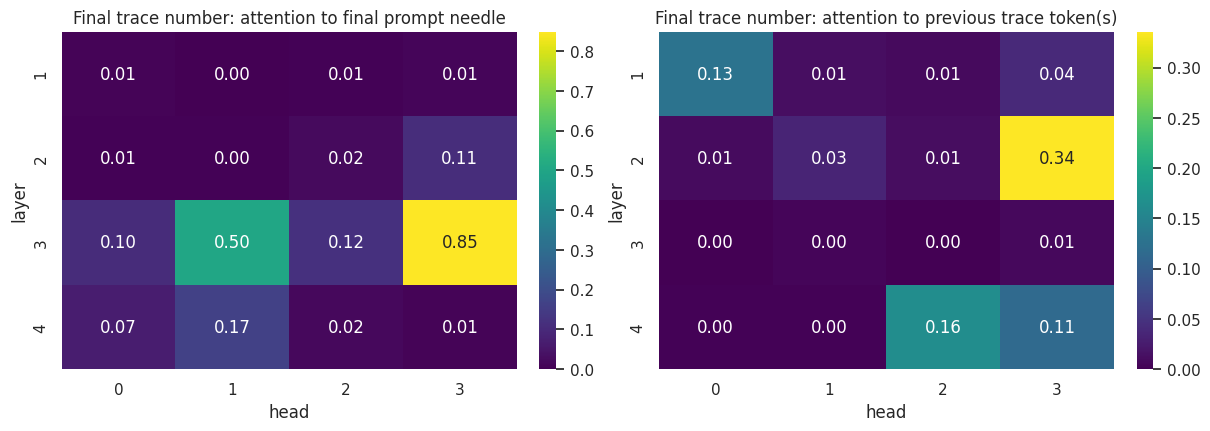

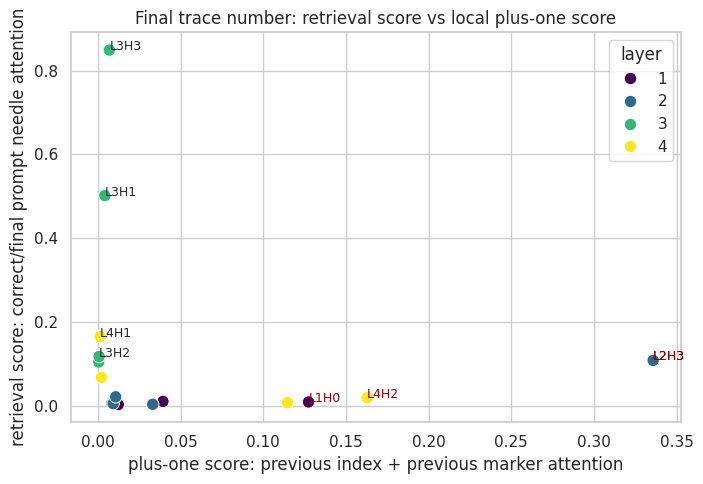

**Best final-index retrieval head:** L3H3, retrieval=0.849, plus_one=0.007.

**Best local plus-one head:** L2H3, retrieval=0.108, plus_one=0.336.

In [11]:
def savefig(name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, bbox_inches="tight", dpi=180)
    plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "retrieval_score", "Final trace number: attention to final prompt needle"),
    (axes[1], "plus_one_score", "Final trace number: attention to previous trace token(s)"),
]:
    mat = last_index_head_summary.pivot(index="layer", columns="head", values=metric)
    sns.heatmap(mat, ax=ax, cmap="viridis", vmin=0, vmax=max(0.05, float(mat.max().max())), annot=True, fmt=".2f")
    ax.set_title(title)
    ax.set_xlabel("head")
    ax.set_ylabel("layer")
plt.savefig(FIG_DIR / "last_index_retrieval_vs_plus_one_heatmaps.png", bbox_inches="tight", dpi=180)
plt.show()

plot_df = last_index_head_summary.copy()
plot_df["label"] = "L" + plot_df["layer"].astype(str) + "H" + plot_df["head"].astype(str)
plt.figure(figsize=(7.2, 5.0))
sns.scatterplot(data=plot_df, x="plus_one_score", y="retrieval_score", hue="layer", palette="viridis", s=80)
for _, row in plot_df.sort_values("retrieval_score", ascending=False).head(5).iterrows():
    plt.text(row["plus_one_score"], row["retrieval_score"], row["label"], fontsize=9)
for _, row in plot_df.sort_values("plus_one_score", ascending=False).head(3).iterrows():
    plt.text(row["plus_one_score"], row["retrieval_score"], row["label"], fontsize=9, color="darkred")
plt.title("Final trace number: retrieval score vs local plus-one score")
plt.xlabel("plus-one score: previous index + previous marker attention")
plt.ylabel("retrieval score: correct/final prompt needle attention")
savefig("last_index_retrieval_vs_plus_one_scatter.png")

best_retrieval = last_index_head_summary.sort_values(["retrieval_score", "correct_prompt_needle_top1"], ascending=False).iloc[0]
best_plus_one = last_index_head_summary.sort_values("plus_one_score", ascending=False).iloc[0]
BEST_RETRIEVAL_LAYER = int(best_retrieval["layer"])
BEST_RETRIEVAL_HEAD = int(best_retrieval["head"])
BEST_PLUS_LAYER = int(best_plus_one["layer"])
BEST_PLUS_HEAD = int(best_plus_one["head"])

display(Markdown(
    f"**Best final-index retrieval head:** L{BEST_RETRIEVAL_LAYER}H{BEST_RETRIEVAL_HEAD}, "
    f"retrieval={best_retrieval['retrieval_score']:.3f}, plus_one={best_retrieval['plus_one_score']:.3f}."
))
display(Markdown(
    f"**Best local plus-one head:** L{BEST_PLUS_LAYER}H{BEST_PLUS_HEAD}, "
    f"retrieval={best_plus_one['retrieval_score']:.3f}, plus_one={best_plus_one['plus_one_score']:.3f}."
))
        

## 7. Category-Mass Bar Plots

第一张柱状图只看最强 retrieval head。
第二张柱状图把所有 layer/head 平均起来，作为“整体 attention 倾向”的粗略参考。

**横轴**：token 类别。
**纵轴**：attention mass，越高说明 query 对该类 token 分配越多注意力。
        

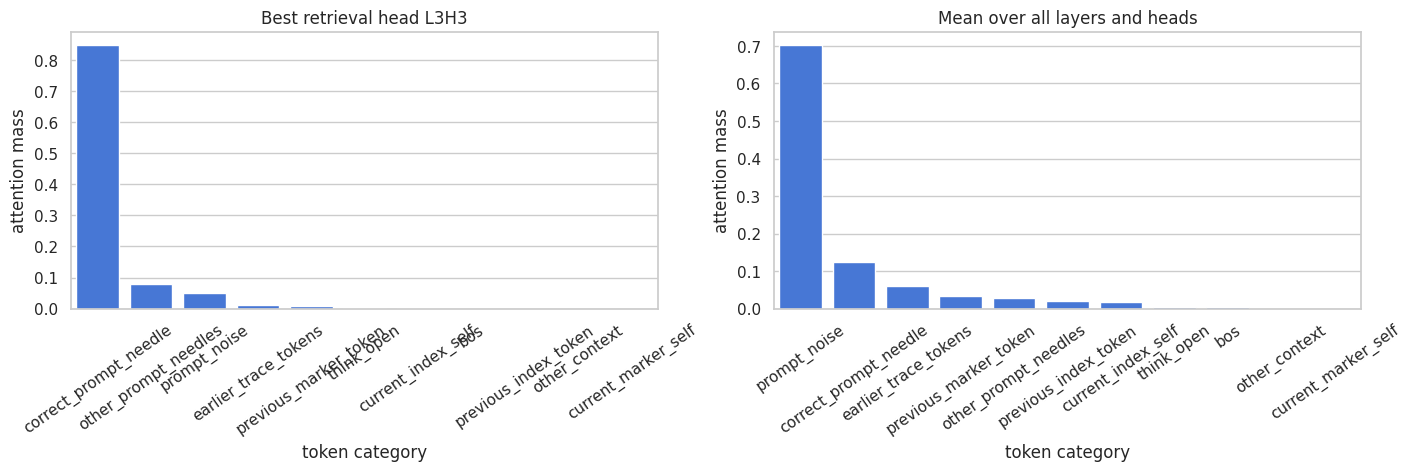

**Category mass for best retrieval head.**

,category,attention_mass
0,correct_prompt_needle,8.492135e-01
1,other_prompt_needles,7.799524e-02
2,prompt_noise,5.160373e-02
7,earlier_trace_tokens,1.026157e-02
6,previous_marker_token,6.772783e-03
8,think_open,2.786153e-03
3,current_index_self,9.974043e-04
9,bos,2.103535e-04
5,previous_index_token,1.592779e-04
10,other_context,2.923597e-08


**Category mass averaged over all heads/layers.**

,category,attention_mass
2,prompt_noise,7.029425e-01
0,correct_prompt_needle,1.249492e-01
7,earlier_trace_tokens,6.125212e-02
6,previous_marker_token,3.372256e-02
1,other_prompt_needles,2.938897e-02
5,previous_index_token,2.066525e-02
3,current_index_self,1.673503e-02
8,think_open,5.462050e-03
9,bos,4.882331e-03
10,other_context,2.365586e-08


In [12]:
def category_summary_for(layer: int | None = None, head: int | None = None) -> pd.DataFrame:
    sub = attention_df[(attention_df["query_anchor"] == "index_token_k") & (attention_df["is_last_index"])]
    if layer is not None and head is not None:
        sub = sub[(sub["layer"] == layer) & (sub["head"] == head)]
    vals = sub[CATEGORY_COLUMNS].mean().reset_index()
    vals.columns = ["category", "attention_mass"]
    vals = vals.sort_values("attention_mass", ascending=False)
    return vals


best_cat = category_summary_for(BEST_RETRIEVAL_LAYER, BEST_RETRIEVAL_HEAD)
all_cat = category_summary_for()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)
for ax, data, title in [
    (axes[0], best_cat, f"Best retrieval head L{BEST_RETRIEVAL_LAYER}H{BEST_RETRIEVAL_HEAD}"),
    (axes[1], all_cat, "Mean over all layers and heads"),
]:
    sns.barplot(data=data, x="category", y="attention_mass", ax=ax, color="#2f6fed")
    ax.set_title(title)
    ax.set_xlabel("token category")
    ax.set_ylabel("attention mass")
    ax.tick_params(axis="x", rotation=35)
plt.savefig(FIG_DIR / "last_index_category_mass_bars.png", bbox_inches="tight", dpi=180)
plt.show()

display(Markdown("**Category mass for best retrieval head.**"))
display(best_cat)
display(Markdown("**Category mass averaged over all heads/layers.**"))
display(all_cat)
        

## 8. Top-Attended Tokens for the Best Retrieval Head

这一节展示具体 token，而不是类别平均值。
每行是一条样本中最后一个 trace 数字 `<n>` 的 query。`top_role` 说明该 head 最关注的 token 是 prompt needle、prompt noise、trace index 还是别的东西。
        

In [13]:
top_rows = attention_df[
    (attention_df["query_anchor"] == "index_token_k")
    & (attention_df["is_last_index"])
    & (attention_df["layer"] == BEST_RETRIEVAL_LAYER)
    & (attention_df["head"] == BEST_RETRIEVAL_HEAD)
].copy()

role_summary = (
    top_rows
    .groupby("top_role", as_index=False)
    .agg(n=("top_role", "size"), mean_retrieval=("retrieval_score", "mean"), mean_plus_one=("plus_one_score", "mean"))
    .sort_values("n", ascending=False)
)
display(role_summary)

display(top_rows[[
    "example_id", "count", "k", "query_token", "top_token", "top_role",
    "retrieval_score", "plus_one_score", "correct_prompt_needle_mass",
    "previous_index_token_mass", "previous_marker_token_mass",
]].head(20))
        

,top_role,n,mean_retrieval,mean_plus_one
0,prompt_needle_1,40,0.929101,0.000000
1,prompt_needle_10,40,0.793628,0.055427
2,prompt_needle_2,40,0.879640,0.002957
3,prompt_needle_3,40,0.912317,0.002259
4,prompt_needle_4,40,0.858042,0.003790
5,prompt_needle_5,40,0.827840,0.000570
6,prompt_needle_6,40,0.824474,0.002442
7,prompt_needle_7,40,0.807674,0.001348
8,prompt_needle_8,40,0.811858,0.000199
9,prompt_needle_9,40,0.847560,0.000328


,example_id,count,k,query_token,top_token,top_role,retrieval_score,plus_one_score,correct_prompt_needle_mass,previous_index_token_mass,previous_marker_token_mass
59,0,2,2,<2>,<C>,prompt_needle_2,0.832067,0.002460,0.832067,7.438498e-07,0.002460
379,1,9,9,<9>,<J>,prompt_needle_9,0.845221,0.000259,0.845221,1.388976e-04,0.000121
555,2,1,1,<1>,<G>,prompt_needle_1,0.935288,0.000000,0.935288,0.000000e+00,0.000000
827,3,8,8,<8>,<I>,prompt_needle_8,0.857210,0.000639,0.857210,3.576691e-05,0.000604
987,4,1,1,<1>,<A>,prompt_needle_1,0.931043,0.000000,0.931043,0.000000e+00,0.000000
1227,5,7,7,<7>,<I>,prompt_needle_7,0.851572,0.001113,0.851572,2.325749e-05,0.001090
1403,6,2,2,<2>,<I>,prompt_needle_2,0.913073,0.003116,0.913073,1.120049e-06,0.003115
1723,7,9,9,<9>,<I>,prompt_needle_9,0.906267,0.000151,0.906267,1.071785e-04,0.000044
2187,8,10,10,<10>,<G>,prompt_needle_10,0.875891,0.034437,0.875891,5.239287e-04,0.033913
2539,9,6,6,<6>,<A>,prompt_needle_6,0.857395,0.003097,0.857395,3.594576e-05,0.003061


## 9. Lightweight Head Ablation

Attention 本身只是相关性证据。这里做一个小规模 causal sanity check：在 autoregressive thinking 生成时，把某些 head 的 attention output 清零，再看 trace 和最终答案是否下降。

**条件定义：**

- `baseline_no_ablation`：不 ablate；
- `best_retrieval`：最后 trace 数字最关注正确 prompt needle 的 head；
- `top2_retrieval`：retrieval score 前两个 head 同时 ablate；
- `best_plus_one`：最关注上一个 trace 数字/marker 的 head；
- `low_score_control`：retrieval 和 plus-one 都较低的 control head。

**纵轴指标：**

- `accuracy`：最终 `<Ans>` 后的 count 是否正确；
- `trace_exact_match_rate`：整个 trace 是否完全等于 gold trace；
- `trace_marker_recall`：gold marker 有多少被 trace 找回；
- `trace_index_accuracy`：`<1>, <2>, ...` 这些 trace 数字位置是否正确；
- `invalid_rate`：没有生成合法 final count 的比例。
        

head ablation conditions:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

thinking generation:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

thinking generation:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

thinking generation:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

thinking generation:   0%|          | 0/7 [00:00<?, ?it/s]

,accuracy,invalid_rate,trace_exact_match_rate,trace_marker_recall,trace_index_accuracy,condition,heads,n_examples
0,1.000,0.000,1.000,1.000000,1.000,baseline_no_ablation,[],400
1,1.000,0.000,0.995,0.999583,1.000,best_retrieval_L3H3,"[[3, 3]]",400
2,0.995,0.005,0.955,0.994028,0.997,top2_retrieval_L3H3_L3H1,"[[3, 3], [3, 1]]",400
3,1.000,0.000,1.000,1.000000,1.000,best_plus_one_L2H3,"[[2, 3]]",400
4,1.000,0.000,1.000,1.000000,1.000,low_score_control_L2H0,"[[2, 0]]",400


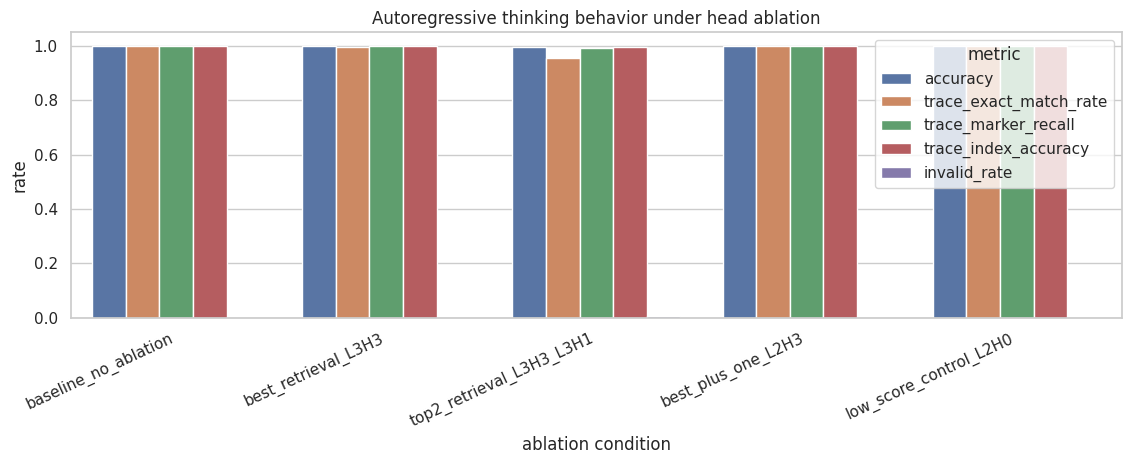

In [14]:
def parse_thinking_generation(generated_tokens: list[str], ex: BaseExample, vocab: Vocab) -> dict[str, Any]:
    ans_generated = "<Ans>" in generated_tokens
    pred_count = None
    invalid = True
    if ans_generated:
        ans_idx = generated_tokens.index("<Ans>")
        if ans_idx + 1 < len(generated_tokens):
            pred_count = vocab.token_to_count(generated_tokens[ans_idx + 1])
            invalid = pred_count is None
    trace_end = generated_tokens.index("</Think>") if "</Think>" in generated_tokens else len(generated_tokens)
    generated_trace = generated_tokens[:trace_end]
    expected_trace = [tok for k, marker in enumerate(ex.needle_markers, start=1) for tok in (vocab.count_to_token(k), marker)]
    expected_markers = [tok for tok in expected_trace if tok in MARKER_TOKENS]
    generated_markers = [tok for tok in generated_trace if tok in MARKER_TOKENS]
    expected_counts = pd.Series(expected_markers).value_counts()
    generated_counts = pd.Series(generated_markers).value_counts()
    if expected_markers or generated_markers:
        overlap = float(pd.concat([expected_counts, generated_counts], axis=1).fillna(0).min(axis=1).sum())
    else:
        overlap = 0.0
    marker_recall = 1.0 if not expected_markers else overlap / len(expected_markers)
    expected_indices = expected_trace[0::2]
    correct_indices = 0
    for i, tok in enumerate(expected_indices):
        pos = 2 * i
        correct_indices += int(pos < len(generated_trace) and generated_trace[pos] == tok)
    trace_index_accuracy = correct_indices / max(len(expected_indices), 1)
    return {
        "pred_count": pred_count,
        "invalid": invalid,
        "ans_generated": ans_generated,
        "trace_exact_match": generated_trace == expected_trace,
        "trace_marker_recall": marker_recall,
        "trace_index_accuracy": trace_index_accuracy,
        "generated_tokens": generated_tokens,
    }


@torch.no_grad()
def predict_thinking(model: GPT2LMHeadModel, examples: list[BaseExample], vocab: Vocab, cfg: dict[str, Any], batch_size: int = 64) -> list[dict[str, Any]]:
    model.eval()
    rows = []
    device = cfg["device"]
    max_new = 2 * int(cfg.get("max_count", 10)) + 4
    for start in tqdm(range(0, len(examples), batch_size), desc="thinking generation", leave=False):
        batch_examples = examples[start : start + batch_size]
        prefixes = [vocab.encode(build_thinking_prefix(ex, vocab)) for ex in batch_examples]
        ids = torch.tensor(prefixes, dtype=torch.long, device=device)
        prefix_len = ids.shape[1]
        finished = torch.zeros(len(batch_examples), dtype=torch.bool, device=device)
        for _ in range(max_new):
            attention_mask = torch.ones_like(ids)
            logits = model(input_ids=ids, attention_mask=attention_mask).logits[:, -1, :]
            next_ids = torch.argmax(logits, dim=-1)
            next_ids = torch.where(finished, torch.full_like(next_ids, vocab.pad_id), next_ids)
            ids = torch.cat([ids, next_ids[:, None]], dim=1)
            finished |= next_ids.eq(vocab.eos_id)
            if bool(finished.all()):
                break
        gen_ids = ids[:, prefix_len:].detach().cpu().tolist()
        for ex, gen in zip(batch_examples, gen_ids):
            toks = [tok for tok in vocab.decode(gen) if tok != "<PAD>"]
            parsed = parse_thinking_generation(toks, ex, vocab)
            rows.append({"count": ex.count, "count_bin": count_bin(ex.count), **parsed})
    return rows


@contextmanager
def ablate_attention_heads(model: GPT2LMHeadModel, heads: list[tuple[int, int]]):
    by_layer: dict[int, list[int]] = {}
    for layer, head in heads:
        by_layer.setdefault(int(layer), []).append(int(head))
    handles = []
    try:
        for layer, head_ids in by_layer.items():
            attn = model.transformer.h[layer - 1].attn
            head_dim = model.config.n_embd // model.config.n_head

            def make_hook(selected_heads: list[int], dim: int):
                def pre_hook(module, inputs):
                    x = inputs[0].clone()
                    for h in selected_heads:
                        start = h * dim
                        stop = start + dim
                        x[..., start:stop] = 0.0
                    return (x,) + tuple(inputs[1:])
                return pre_hook

            handles.append(attn.c_proj.register_forward_pre_hook(make_hook(head_ids, head_dim)))
        yield
    finally:
        for handle in handles:
            handle.remove()


def summarize_prediction_rows(rows: list[dict[str, Any]]) -> dict[str, float]:
    df = pd.DataFrame(rows)
    correct = df["pred_count"].fillna(-999).astype(int).eq(df["count"].astype(int))
    return {
        "accuracy": float(correct.mean()),
        "invalid_rate": float(df["invalid"].mean()),
        "trace_exact_match_rate": float(df["trace_exact_match"].mean()),
        "trace_marker_recall": float(df["trace_marker_recall"].mean()),
        "trace_index_accuracy": float(df["trace_index_accuracy"].mean()),
    }


def choose_control_head(summary: pd.DataFrame, avoid: set[tuple[int, int]]) -> tuple[int, int]:
    tmp = summary.copy()
    tmp["combined"] = tmp["retrieval_score"] + tmp["plus_one_score"]
    tmp = tmp.sort_values("combined")
    for _, row in tmp.iterrows():
        key = (int(row["layer"]), int(row["head"]))
        if key not in avoid:
            return key
    return (1, 0)


ablation_path = TABLE_DIR / "head_ablation_results.csv"
if RUN_HEAD_ABLATION:
    if REUSE_EXISTING_TABLES and ablation_path.exists():
        ablation_df = pd.read_csv(ablation_path)
    else:
        top2 = [
            (int(row["layer"]), int(row["head"]))
            for _, row in last_index_head_summary.sort_values("retrieval_score", ascending=False).head(2).iterrows()
        ]
        best_retrieval_head = (BEST_RETRIEVAL_LAYER, BEST_RETRIEVAL_HEAD)
        best_plus_head = (BEST_PLUS_LAYER, BEST_PLUS_HEAD)
        control_head = choose_control_head(last_index_head_summary, set(top2 + [best_plus_head]))
        conditions = [
            ("baseline_no_ablation", []),
            (f"best_retrieval_L{best_retrieval_head[0]}H{best_retrieval_head[1]}", [best_retrieval_head]),
            ("top2_retrieval_" + "_".join([f"L{l}H{h}" for l, h in top2]), top2),
            (f"best_plus_one_L{best_plus_head[0]}H{best_plus_head[1]}", [best_plus_head]),
            (f"low_score_control_L{control_head[0]}H{control_head[1]}", [control_head]),
        ]
        ablation_examples = balanced_examples(int(cfg["seq_len"]), ABLATION_EXAMPLES_PER_COUNT, RANDOM_SEED + 4001)
        rows = []
        for name, heads in tqdm(conditions, desc="head ablation conditions"):
            model = load_gpt2_eager(THINKING_MODEL_DIR)
            if heads:
                with ablate_attention_heads(model, heads):
                    preds = predict_thinking(model, ablation_examples, vocab, cfg, batch_size=64)
            else:
                preds = predict_thinking(model, ablation_examples, vocab, cfg, batch_size=64)
            metrics = summarize_prediction_rows(preds)
            metrics.update({"condition": name, "heads": json.dumps(heads), "n_examples": len(ablation_examples)})
            rows.append(metrics)
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        ablation_df = pd.DataFrame(rows)
        ablation_df.to_csv(ablation_path, index=False)
else:
    ablation_df = pd.read_csv(ablation_path)

display(ablation_df)

plot_long = ablation_df.melt(
    id_vars=["condition"],
    value_vars=["accuracy", "trace_exact_match_rate", "trace_marker_recall", "trace_index_accuracy", "invalid_rate"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(11.5, 4.8))
sns.barplot(data=plot_long, x="condition", y="value", hue="metric")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.title("Autoregressive thinking behavior under head ablation")
plt.xlabel("ablation condition")
plt.ylabel("rate")
savefig("head_ablation_results.png")
        

## 10. Save Analysis Bundle to Google Drive  

In [16]:
SAVE_RESULTS = True
DRIVE_RESULTS_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results")
LOCAL_RESULTS_ROOT = Path("colab_results")
DRIVE_SAVE_COMPLETED = False

if SAVE_RESULTS:
    if IN_COLAB:
        from google.colab import drive

        drive.mount("/content/drive")
        results_root = DRIVE_RESULTS_ROOT
    else:
        results_root = LOCAL_RESULTS_ROOT
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    bundle_dir = results_root / f"v3_v2_attention_deepdive_seed{RANDOM_SEED}_{timestamp}"
    bundle_dir.mkdir(parents=True, exist_ok=True)
    shutil.copytree(ANALYSIS_DIR, bundle_dir / "analysis", dirs_exist_ok=True)
    nb_src = Path("notebooks/Trace_Count_v3_Colab.ipynb")
    if nb_src.exists():
        (bundle_dir / "notebooks").mkdir(exist_ok=True)
        shutil.copy2(nb_src, bundle_dir / "notebooks" / nb_src.name)
    manifest = {
        "source_v2_run_dir": str(V2_RUN_DIR),
        "thinking_model_dir": str(THINKING_MODEL_DIR),
        "analysis_dir": str(ANALYSIS_DIR),
        "attention_examples_per_count": ATTENTION_EXAMPLES_PER_COUNT,
        "ablation_examples_per_count": ABLATION_EXAMPLES_PER_COUNT,
        "saved_at": timestamp,
    }
    (bundle_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    if IN_COLAB:
        DRIVE_SAVE_COMPLETED = True
    print("Saved:", bundle_dir)
        

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: /content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v3_v2_attention_deepdive_seed1234_20260708_053824


## 12. Auto-disconnect Colab Runtime

这个 cell 放在 Google Drive 保存之后。默认只在确认已经保存到 Google Drive 后断开 Colab runtime；本地 VSCode/Jupyter 不会被强制关闭。
        

In [17]:
AUTO_DISCONNECT_AFTER_DRIVE_SAVE = True
FORCE_LOCAL_KERNEL_SHUTDOWN = False

if AUTO_DISCONNECT_AFTER_DRIVE_SAVE and globals().get("DRIVE_SAVE_COMPLETED", False):
    import time

    print("Google Drive save completed. Flushing Drive and disconnecting Colab runtime in 3 seconds...")
    time.sleep(3)
    try:
        from google.colab import drive, runtime

        try:
            drive.flush_and_unmount()
            print("Google Drive flushed and unmounted.")
        except Exception as e:
            print(f"Drive flush/unmount skipped or failed: {e}")
        runtime.unassign()
    except Exception as e:
        print(f"Colab runtime disconnect unavailable or failed: {e}")
        if FORCE_LOCAL_KERNEL_SHUTDOWN:
            import IPython

            IPython.Application.instance().kernel.do_shutdown(restart=False)
        else:
            print("Not forcing local kernel shutdown.")
else:
    print("Auto-disconnect skipped: no confirmed Google Drive save, or AUTO_DISCONNECT_AFTER_DRIVE_SAVE is False.")
        

Google Drive save completed. Flushing Drive and disconnecting Colab runtime in 3 seconds...
Google Drive flushed and unmounted.


## 13. Optional GitHub Push

默认关闭。这个 cell 只提交 notebook / pipeline / builder，不提交大型 run outputs。
        

In [18]:
PUSH_TO_GITHUB = False
GIT_COMMIT_MESSAGE = "Rewrite v3 as v2 attention-head deep dive"

if PUSH_TO_GITHUB:
    subprocess.run(["git", "status", "--short"], check=False)
    subprocess.run(
        [
            "git",
            "add",
            "notebooks/Trace_Count_v3_Colab.ipynb",
            "notebooks/pipeline_v3_codex_prompt.md",
            "scripts/build_v3_notebook.py",
            "README.md",
        ],
        check=True,
    )
    subprocess.run(["git", "commit", "-m", GIT_COMMIT_MESSAGE], check=False)
    subprocess.run(["git", "push"], check=True)
else:
    print("PUSH_TO_GITHUB is False; no git commands were run.")
        

PUSH_TO_GITHUB is False; no git commands were run.
